## Setup

In [1]:
import os, sys
from pathlib import Path
root = Path.cwd()
while not (root / 'ROADMAP.md').exists() and root != root.parent:
    root = root.parent
os.chdir(root); sys.path.insert(0, str(root))
print('repo root:', root)

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.models.model_example import PersonalVAD
from src.models.dataset_example import (
    SceneFeatureDataset, compute_mel_stats, compute_class_weights,
)
from src.models.train_example import evaluate   # per-frame target-only metrics on a dataset

repo root: /Users/ihsanbolum/Target Person Voice


## Config

Point `TRAIN_DIR` / `VAL_DIR` at the **clean** cache for the main model, or at
`data/features_noisy/...` to draw the learning curve for the noisy model.

In [2]:
TRAIN_DIR = root / 'data' / 'features_noisy' / 'train'     # or 'features_noisy' / 'train'
VAL_DIR   = root / 'data' / 'features_noisy' / 'val'        # or 'features_noisy' / 'val'

SUBSET_SIZES = [25, 50, 75, 100, 120, 150]
EPOCHS, PATIENCE, LR, SEED = 25, 5, 1e-3, 0

## Training subroutine

`Subset` is a thin view so we can train on the first *n* scenes while reusing the
exact same dataset/stats/weight helpers as real training. `train_on_subset` trains a
fresh head on *n* scenes, early-stops on val F1, and returns the best val F1 plus the
train F1 at that point (for the gap).

In [3]:
class Subset:
    """A view over the first-n scenes of a SceneFeatureDataset."""
    def __init__(self, ds, indices):
        self.ds, self.indices = ds, list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        return self.ds[self.indices[i]]

full_train = SceneFeatureDataset(TRAIN_DIR)
val_ds = SceneFeatureDataset(VAL_DIR)
print(f'{len(full_train)} train scenes cached, {len(val_ds)} val scenes')

def train_on_subset(n):
    """Train a fresh head on the first n scenes. Returns (best_val_f1, train_f1_at_best)."""
    torch.manual_seed(SEED); np.random.seed(SEED)
    subset = Subset(full_train, range(n))

    # Normalization + class balance from THIS subset only (no val leakage).
    mel_mean, mel_std = compute_mel_stats(subset)
    weights = compute_class_weights(subset)

    model = PersonalVAD(); model.set_mel_stats(mel_mean, mel_std)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    best_val, best_state, since = -1.0, None, 0
    order = np.arange(n)
    for _ in range(EPOCHS):
        model.train(); np.random.shuffle(order)
        for idx in order:
            s = subset[int(idx)]
            opt.zero_grad()
            logits = model(s['mel'][None], s['emb'][None], s['cos'][None], s['vad'][None], s['e_target'][None])
            loss = loss_fn(logits.reshape(-1, 4), s['labels'].reshape(-1))
            loss.backward(); opt.step()
        f1 = evaluate(model, val_ds).f1 or -1.0
        if f1 > best_val:
            best_val = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            since = 0
        else:
            since += 1
        if since >= PATIENCE:
            break
    model.load_state_dict(best_state)
    train_f1 = evaluate(model, subset).f1 or -1.0   # fit on its own training scenes
    return best_val, train_f1

150 train scenes cached, 20 val scenes


## Run the sweep

In [4]:
results = []
for n in SUBSET_SIZES:
    val_f1, train_f1 = train_on_subset(n)
    results.append((n, train_f1, val_f1))
    print(f'n={n:3d}   train F1={train_f1:.3f}   val F1={val_f1:.3f}   gap={train_f1 - val_f1:+.3f}')

n= 25   train F1=0.870   val F1=0.810   gap=+0.060
n= 50   train F1=0.836   val F1=0.793   gap=+0.043
n= 75   train F1=0.823   val F1=0.816   gap=+0.007
n=100   train F1=0.833   val F1=0.798   gap=+0.035
n=120   train F1=0.821   val F1=0.806   gap=+0.015
n=150   train F1=0.898   val F1=0.821   gap=+0.077


lstm - features_noisy

n= 25   train F1=0.788   val F1=0.760   gap=+0.027
n= 50   train F1=0.820   val F1=0.788   gap=+0.031
n= 75   train F1=0.811   val F1=0.794   gap=+0.017
n=100   train F1=0.835   val F1=0.792   gap=+0.043
n=120   train F1=0.825   val F1=0.802   gap=+0.023
n=150   train F1=0.857   val F1=0.775   gap=+0.081


bilstm - features_noisy 

n= 25   train F1=0.870   val F1=0.810   gap=+0.060
n= 50   train F1=0.836   val F1=0.793   gap=+0.043
n= 75   train F1=0.823   val F1=0.816   gap=+0.007
n=100   train F1=0.833   val F1=0.798   gap=+0.035
n=120   train F1=0.821   val F1=0.806   gap=+0.015
n=150   train F1=0.898   val F1=0.821   gap=+0.077


## The learning curve

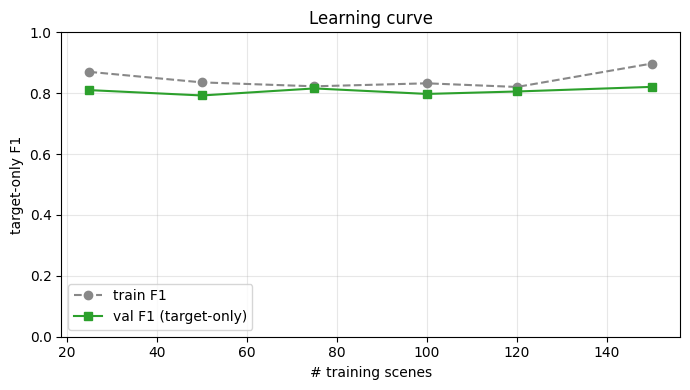

In [5]:
ns = [r[0] for r in results]
tr = [r[1] for r in results]
va = [r[2] for r in results]

plt.figure(figsize=(7, 4))
plt.plot(ns, tr, 'o--', label='train F1', color='#888888')
plt.plot(ns, va, 's-', label='val F1 (target-only)', color='#2ca02c')
plt.xlabel('# training scenes'); plt.ylabel('target-only F1')
plt.title('Learning curve'); plt.ylim(0, 1)
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()